In [3]:
import pandas as pd

In [4]:
!pip install kaggle



In [5]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"faitholaniyi","key":"9ea357793b9f0ad9897e5a2e226fb301"}'}

In [6]:
# Set it up so the kaggle CLI can find it
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download and unzip the dataset
!kaggle datasets download -d mirichoi0218/insurance
!unzip insurance.zip

Dataset URL: https://www.kaggle.com/datasets/mirichoi0218/insurance
License(s): DbCL-1.0
100% 16.0k/16.0k [00:00<00:00, 38.4MB/s]

Archive:  insurance.zip
  inflating: insurance.csv           


In [7]:
df = pd.read_csv('insurance.csv')

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

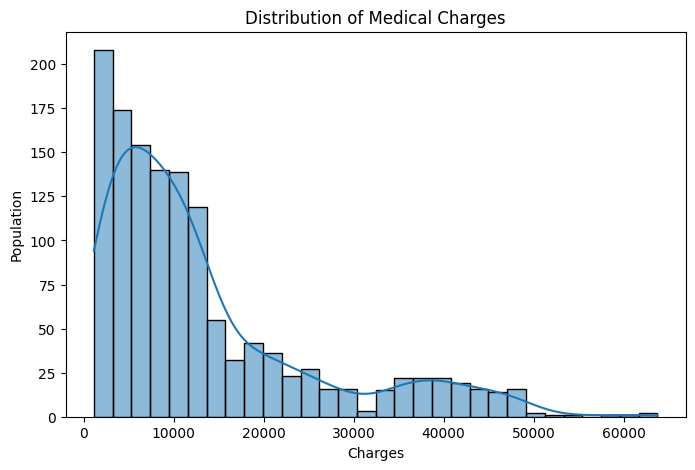

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(df['charges'], bins=30, kde=True)
plt.title('Distribution of Medical Charges')
plt.xlabel('Charges')
plt.ylabel('Population')
plt.show()

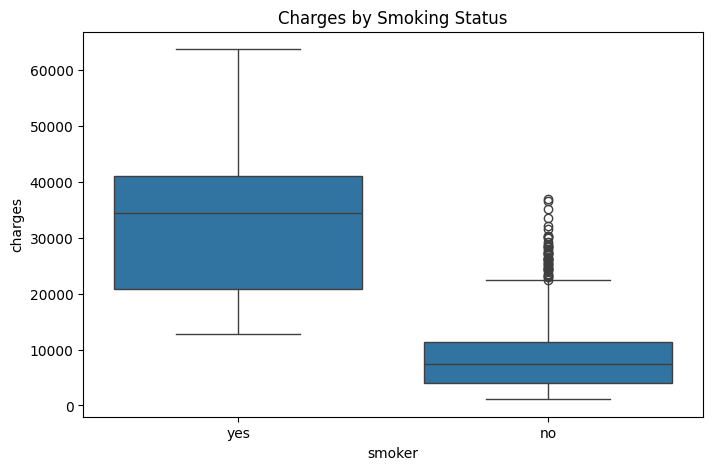

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges by Smoking Status')
plt.show()

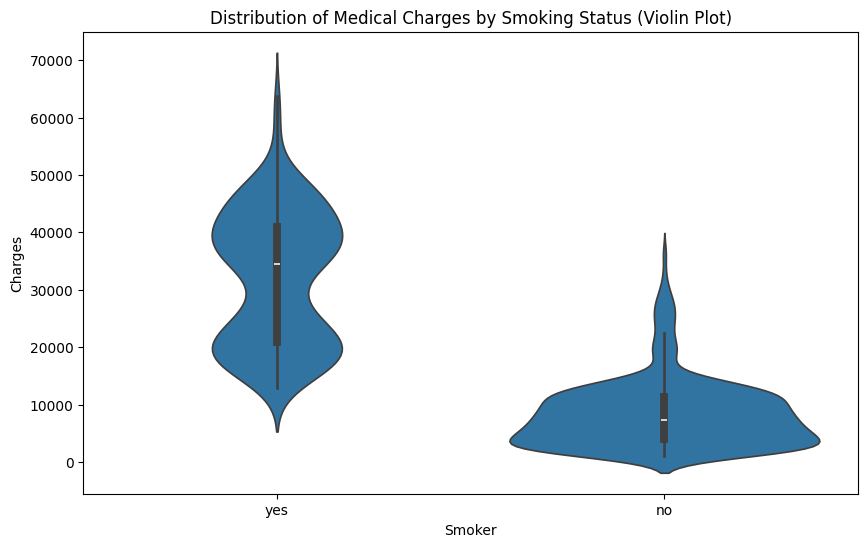

In [13]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='smoker', y='charges', data=df)
plt.title('Distribution of Medical Charges by Smoking Status (Violin Plot)')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.show()

 A violin plot is a box plot with the shape of the distribution drawn around it. Where the violin is wide, a lot of data points sit around that value; where it's narrow, fewer do. Many versions also draw a small box or line inside marking the median and the middle 50% of the data, similar to a regular box plot.
 If a violin has two separate bulges rather than one smooth shape, that can mean there are actually two subgroups hiding inside that category, something a plain box plot wouldn't show as clearly.

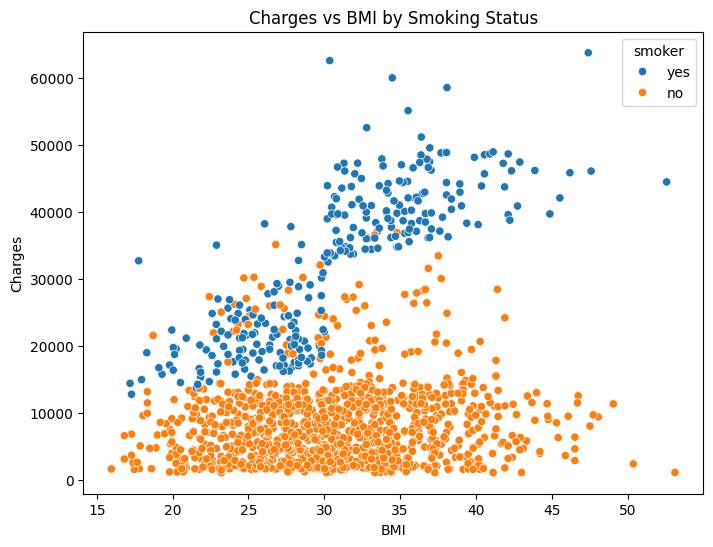

In [14]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker')
plt.title('Charges vs BMI by Smoking Status')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()

Look at the smoker (blue) points: there's a visible jump right around BMI = 30. Below that, smoker charges sit in a band roughly between 13000 and 30000. At and above BMI = 30, they jump to a much higher band, roughly 33000 to 63000. That's exactly the two-hump pattern from the violin plot, and BMI is the variable driving it.
A BMI of 30 or higher is the standard benchmark used to define obesity in adults. From a health perspective, reaching this threshold indicates an increased statistical risk for several chronic conditions, though BMI does not measure body fat directly.

For non-smokers (orange), the pattern looks different, they form a fairly tight band across the whole BMI range, mostly under 15000, with a scatter of higher points reaching up to around 30000-35000. Those higher orange points don't look concentrated at any particular BMI, so whatever is pushing those non-smokers' costs up, it doesn't appear to be BMI on its own.

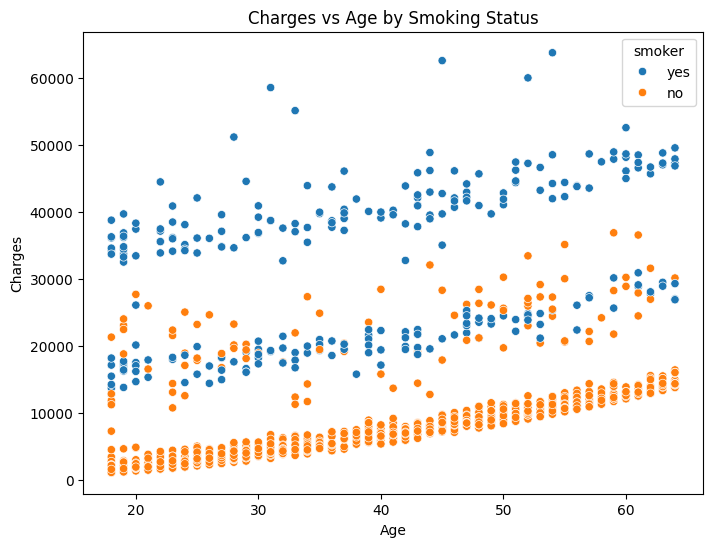

In [15]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker')
plt.title('Charges vs Age by Smoking Status')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()

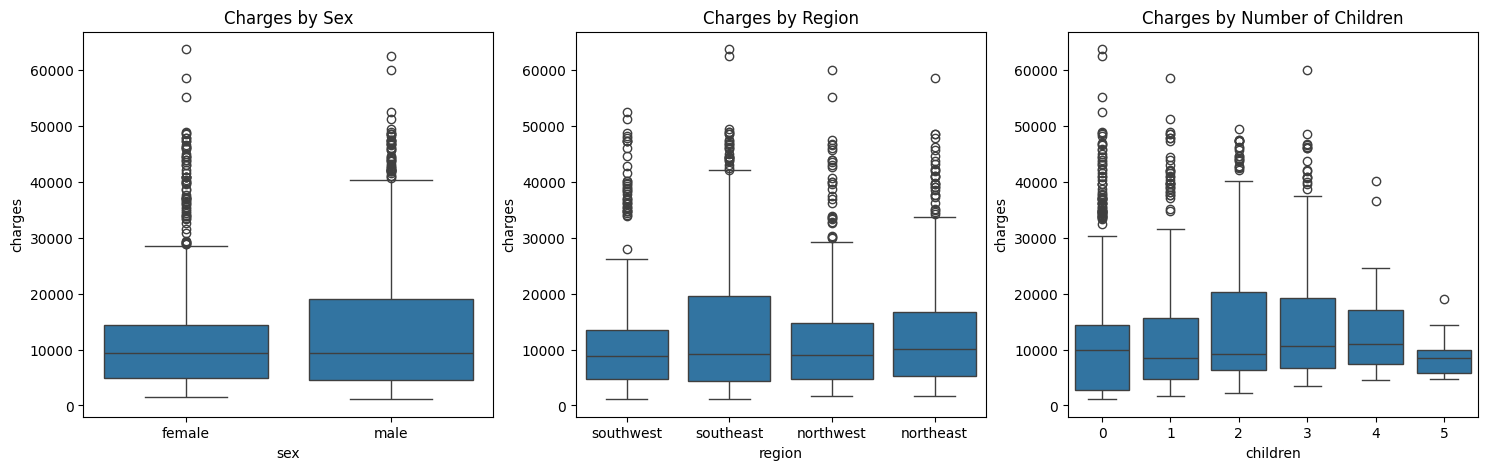

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='sex', y='charges', ax=axes[0])
axes[0].set_title('Charges by Sex')

sns.boxplot(data=df, x='region', y='charges', ax=axes[1])
axes[1].set_title('Charges by Region')

sns.boxplot(data=df, x='children', y='charges', ax=axes[2])
axes[2].set_title('Charges by Number of Children')

plt.show()

In [17]:
df['children'].value_counts().sort_index()

,count
children,
0,574
1,324
2,240
3,157
4,25
5,18


In [18]:
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True).astype(int)
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27,0,16884,0,1,0,0,1
1,18,33,1,1725,1,0,0,1,0
2,28,33,3,4449,1,0,0,1,0
3,33,22,0,21984,1,0,1,0,0
4,32,28,0,3866,1,0,1,0,0


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [20]:
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
numeric_cols = ['age', 'bmi', 'children']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train_scaled.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
560,0.472227,-1.826300,0.734336,0,0,1,0,0
1285,0.543313,-1.001350,-0.911192,0,0,0,0,0
1142,0.898745,-1.001350,-0.911192,0,0,0,1,0
969,-0.025379,0.648549,3.202629,0,0,0,1,0
486,1.040918,-1.496320,1.557100,0,0,1,0,0


In [22]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

coefficients = pd.Series(lr_model.coef_, index=X_train_scaled.columns)
coefficients

,0
age,3616.670487
bmi,2034.266569
children,519.699072
sex_male,-17.262175
smoker_yes,23655.674133
region_northwest,-364.205361
region_southeast,-667.644378
region_southwest,-819.619053


In [23]:
y_pred = lr_model.predict(X_test_scaled)

In [24]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

R²: 0.7838
MAE: 4176.27
RMSE: 5793.66


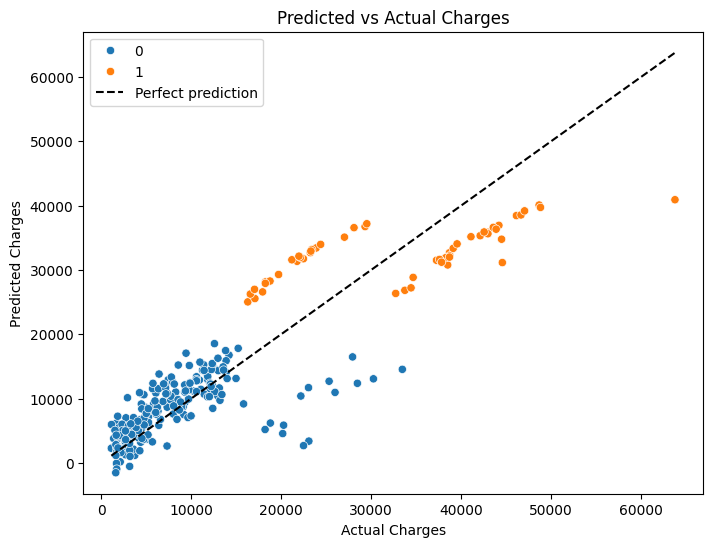

In [25]:
results_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred,
    'smoker': X_test_scaled['smoker_yes'].values
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=results_df, x='actual', y='predicted', hue='smoker')
plt.plot([results_df['actual'].min(), results_df['actual'].max()],
         [results_df['actual'].min(), results_df['actual'].max()], 'k--', label='Perfect prediction')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Predicted vs Actual Charges')
plt.legend()
plt.show()

In [26]:
X_train_scaled['smoker_bmi'] = X_train_scaled['smoker_yes'] * X_train_scaled['bmi']
X_test_scaled['smoker_bmi'] = X_test_scaled['smoker_yes'] * X_test_scaled['bmi']

lr_model_v2 = LinearRegression()
lr_model_v2.fit(X_train_scaled, y_train)

y_pred_v2 = lr_model_v2.predict(X_test_scaled)

r2_v2 = r2_score(y_test, y_pred_v2)
mae_v2 = mean_absolute_error(y_test, y_pred_v2)
rmse_v2 = np.sqrt(mean_squared_error(y_test, y_pred_v2))

print(f"R²: {r2_v2:.4f}")
print(f"MAE: {mae_v2:.2f}")
print(f"RMSE: {rmse_v2:.2f}")

R²: 0.8646
MAE: 2759.93
RMSE: 4585.54


In [28]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [30]:
alphas = [0.1, 1.0, 10.0, 100.0]

print("Ridge Regression Results")

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    y_pred_ridge = ridge.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred_ridge)
    mae = mean_absolute_error(y_test, y_pred_ridge)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

    print(f"Alpha: {alpha}")
    print(f"R²: {r2:.4f} | MAE: {mae:.2f} | RMSE: {rmse:.2f}")
    print()

Ridge Regression Results
Alpha: 0.1
R²: 0.8646 | MAE: 2761.89 | RMSE: 4585.29

Alpha: 1.0
R²: 0.8647 | MAE: 2780.07 | RMSE: 4583.50

Alpha: 10.0
R²: 0.8637 | MAE: 2957.10 | RMSE: 4600.45

Alpha: 100.0
R²: 0.7729 | MAE: 4587.22 | RMSE: 5938.06



In [31]:
print("Lasso Regression Results")

for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train_scaled, y_train)
    y_pred_lasso = lasso.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred_lasso)
    mae = mean_absolute_error(y_test, y_pred_lasso)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

    print(f"Alpha: {alpha}")
    print(f"R²: {r2:.4f} | MAE: {mae:.2f} | RMSE: {rmse:.2f}")
    print()

Lasso Regression Results
Alpha: 0.1
R²: 0.8646 | MAE: 2760.11 | RMSE: 4585.54

Alpha: 1.0
R²: 0.8646 | MAE: 2761.75 | RMSE: 4585.57

Alpha: 10.0
R²: 0.8645 | MAE: 2778.33 | RMSE: 4586.52

Alpha: 100.0
R²: 0.8623 | MAE: 2903.96 | RMSE: 4624.42



Neither Ridge nor Lasso meaningfully improved on the interaction term model. The best Ridge result (alpha 1.0, R² 0.8647) is essentially identical to it, and Lasso at any alpha stays at roughly 0.8646. This is actually a meaningful finding in itself: it suggests our model was not significantly overfitting in the first place. The interaction term model was already fairly well-specified, and regularization confirms that by not finding much room to improve.

In [32]:
lasso_final = Lasso(alpha=0.1)
lasso_final.fit(X_train_scaled, y_train)

coefficients_lasso = pd.Series(lasso_final.coef_, index=X_train_scaled.columns)
print("Lasso Coefficients (alpha=0.1):")
print(coefficients_lasso)

Lasso Coefficients (alpha=0.1):
age                  3713.261554
bmi                   118.718378
children              564.535816
sex_male             -513.106515
smoker_yes          23758.241315
region_northwest     -647.290232
region_southeast     -996.056315
region_southwest    -1242.321862
smoker_bmi           8913.482805
dtype: float64


In [33]:
import joblib

joblib.dump(lr_model_v2, 'medical_cost_model.joblib')
joblib.dump(scaler, 'scaler.joblib')

print("Model and scaler saved.")

Model and scaler saved.


In [34]:
from google.colab import files

files.download('medical_cost_model.joblib')
files.download('scaler.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>